# Homework Starter — Stage 03: Python Fundamentals

## Instructions
Fill in the cells below to complete your homework. Refer to lecture examples.

In [2]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
!pip install numpy
!pip install pandas
!pip install matplotlib

   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.9 MB 560.1 kB/s eta 0:00:23
   - -------------------------------------- 0.5/12.9 MB 560.1 kB/s eta 0:00:23
   -- ------------------------------------- 0.8/12.9 MB 524.3 kB/s eta 0:00:24
   -- ------------------------------------- 0.8/12.9 MB 524.3 kB/s eta 0:00:24
   --- ------------------------------------ 1.0/12.9 MB 572.0 kB/s eta 0:00:21
   --- ------------------------------------ 1.0/12.9 MB 572.0 kB/s eta 0:00:21
   ---- ----------------------------

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. NumPy Operations

In [4]:
# Create a NumPy array
arr = np.array([1, 2, 3, 4, 5])

print("Original array:")
print(arr)

# Elementwise addition
print("\nAdd 10:")
print(arr + 10)

# Elementwise multiplication
print("\nMultiply by 2:")
print(arr * 2)

# Elementwise square
print("\nSquare:")
print(arr ** 2)

Original array:
[1 2 3 4 5]

Add 10:
[11 12 13 14 15]

Multiply by 2:
[ 2  4  6  8 10]

Square:
[ 1  4  9 16 25]


## 2. Compare Loop vs Vectorization

In [5]:
# Create a larger NumPy array for timing comparison
large_arr = np.arange(100000)

# Python loop version
def square_with_loop(arr):
    result = []
    for x in arr:
        result.append(x ** 2)
    return result

# NumPy vectorized version
def square_vectorized(arr):
    return arr ** 2

In [6]:
%timeit square_with_loop(large_arr)

6.16 ms ± 211 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [7]:
%timeit square_vectorized(large_arr)

35.3 μs ± 1.86 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### Observation

The NumPy vectorized operation is much faster than the Python loop because NumPy performs array operations using optimized low-level implementations.

## 3. Load and Inspect Dataset

In [8]:
# Load the dataset
df = pd.read_csv("data/raw/starter_data.csv")

# Display the first five rows
df.head()

,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [9]:
# Inspect dataframe structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes


In [10]:
# Summary statistics for numeric columns
df.describe()

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


## 4. Summary Statistics and Groupby

In [11]:
# Calculate summary statistics for numeric columns
summary_stats = df.describe()
summary_stats

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


In [12]:
df.columns

Index(['category', 'value', 'date'], dtype='object')

In [13]:
grouped_summary = df.groupby("category").mean(numeric_only=True)
grouped_summary

,value
category,
A,11.500000
B,15.666667
C,27.666667


## 5. Reusable Function

In [14]:
def get_summary_stats(dataframe):
    """
    Return summary statistics for numeric columns
    in a pandas DataFrame.
    """
    return dataframe.describe()

In [15]:
summary_from_function = get_summary_stats(df)
summary_from_function

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


In [17]:
summary_stats.to_csv("data/processed/summary.csv")

## 6. Plot

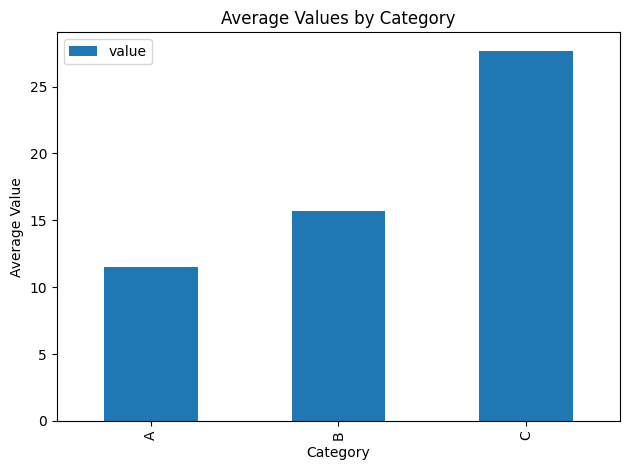

In [18]:
# Create a simple plot
grouped_summary.plot(kind="bar")

plt.title("Average Values by Category")
plt.xlabel("Category")
plt.ylabel("Average Value")
plt.tight_layout()

plt.savefig("reports/category_summary.png")

plt.show()

## 7. Import utils.py in the Notebook

In [19]:
from src.utils import get_summary_stats

In [20]:
summary_stats = get_summary_stats(df)
summary_stats

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000
